Minkowski Distance, Mutual Information, and Token Positions

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import minkowski

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4806.15it/s]

Ready!


In [2]:
import urllib.request


url = "https://www.gutenberg.org/files/2701/2701-0.txt"
with urllib.request.urlopen(url) as f:
    book_text = f.read().decode("utf-8")

sentences = [s.strip() for s in book_text.split(".")
             if len(s.strip()) > 30][:50]


all_embeddings = []
all_positions  = []

for sentence in sentences:
    inputs = tokenizer(sentence,
                      return_tensors="pt",
                      max_length=32,
                      truncation=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
    

    embs = outputs.hidden_states[-1][0]
    
    for pos in range(embs.shape[0]):
        all_embeddings.append(embs[pos].numpy())
        all_positions.append(pos)

X = np.array(all_embeddings)
y = np.array(all_positions)

print(f"Total tokens: {len(y)}")
print(f"Embedding shape: {X.shape}")

Total tokens: 1127
Embedding shape: (1127, 768)


In [3]:
from scipy.spatial.distance import minkowski
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Alag p values test karo
p_values = [1, 2, 3, 5, 10]

print("KNN with different Minkowski distances:")
print(f"\n{'p value':<10} {'Distance':<20} {'R² Score'}")
print("-"*45)

from sklearn.neighbors import KNeighborsRegressor

for p in p_values:
    knn = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=p)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    dist_name = {1: "Manhattan (L1)", 
                 2: "Euclidean (L2)"}.get(p, f"Minkowski (p={p})")
    print(f"{p:<10} {dist_name:<20} {r2:.4f}")

KNN with different Minkowski distances:

p value    Distance             R² Score
---------------------------------------------
1          Manhattan (L1)       0.4400
2          Euclidean (L2)       0.1580
3          Minkowski (p=3)      0.0520
5          Minkowski (p=5)      0.0452
10         Minkowski (p=10)     0.0376


In [4]:
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer


discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', 
                                strategy='uniform')
X_discrete = discretizer.fit_transform(X)


mi_scores = []
for dim in range(X.shape[1]):
    mi = mutual_info_score(
        X_discrete[:, dim].astype(int), 
        y
    )
    mi_scores.append(mi)

mi_scores = np.array(mi_scores)

print(f"Total dimensions: {len(mi_scores)}")
print(f"Max MI:  {mi_scores.max():.4f} at dim {mi_scores.argmax()}")
print(f"Mean MI: {mi_scores.mean():.4f}")
print(f"Top 5 dimensions:")
top5 = mi_scores.argsort()[-5:][::-1]
for dim in top5:
    print(f"  Dim {dim}: MI = {mi_scores[dim]:.4f}")

Total dimensions: 768
Max MI:  0.4208 at dim 373
Mean MI: 0.1372
Top 5 dimensions:
  Dim 373: MI = 0.4208
  Dim 481: MI = 0.3823
  Dim 266: MI = 0.3677
  Dim 87: MI = 0.3062
  Dim 480: MI = 0.2965


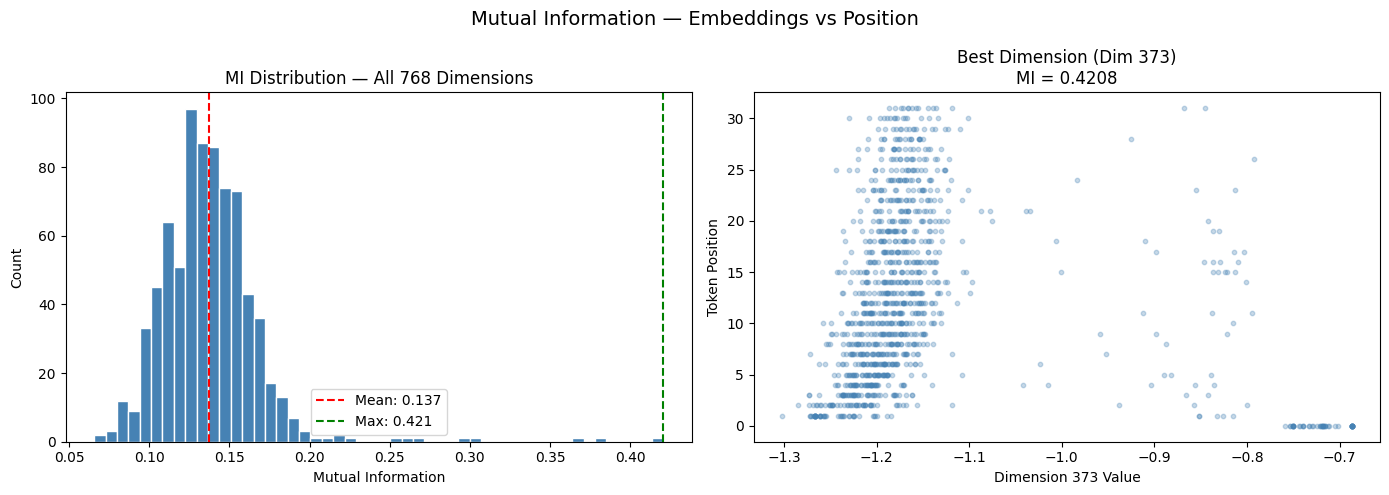

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MI distribution
axes[0].hist(mi_scores, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(x=mi_scores.mean(), color="red", 
                linestyle="--", label=f"Mean: {mi_scores.mean():.3f}")
axes[0].axvline(x=mi_scores.max(), color="green",
                linestyle="--", label=f"Max: {mi_scores.max():.3f}")
axes[0].set_xlabel("Mutual Information")
axes[0].set_ylabel("Count")
axes[0].set_title("MI Distribution — All 768 Dimensions")
axes[0].legend()

# Top dimension scatter
best_dim = mi_scores.argmax()
axes[1].scatter(X[:, best_dim], y, 
                alpha=0.3, color="steelblue", s=10)
axes[1].set_xlabel(f"Dimension {best_dim} Value")
axes[1].set_ylabel("Token Position")
axes[1].set_title(f"Best Dimension (Dim {best_dim})\n"
                  f"MI = {mi_scores[best_dim]:.4f}")

plt.suptitle("Mutual Information — Embeddings vs Position", fontsize=14)
plt.tight_layout()
plt.show()

* Manhattan (L1) distance works best in high-dimensional spaces.
* Dimension 373 carries the most positional information (MI = 0.42).
* Most dimensions have low mutual information — information is sparse.
* Due to the curse of dimensionality, Euclidean distance becomes less effective in high dimensions.
